# Part 1

# TODO: Possibly add prediction error, check all parts are complete, figure out why line is below where it should be, verify in Colab


I used ChatGPT to understand the formulas given in the Linear Regression Optional Reading. I also used it to generate examples of linear regression from a theoretical standpoint in order to better understand the content. All code is my own

I first spent time understanding linear regression better. I read through the optional reading multiple times, and I asked ChatGPT to explain the variables in the mathematical equation. It took some time before I understood the proof behind the given algorithm. After that, I wrote it in Python on my own. On my first attempt, I failed to sum the errors across all data points. After fixing that, the model still did not work. I checked each line individually and found that I accidentally subracted instead of added in one location. 

h(x) = 42.24171624 + (-182.74285376)x + (-53.55440857)x^2  + 86.31677852x^3

I display several plots underneath my code, including the loss graph, slope and bias graphs, and the training and test data with the line of best fit marked. 

In [100]:
!pip install matplotlib
!pip install numpy

In [101]:
import matplotlib.pyplot as plt
import numpy as np

In [102]:
# Define learn function
# num_params is the number of parameters. Ex cubic function is 4 (3 coefficients plus a bias)
def learn(num_epoch, num_params, x_train, y_train):
    alpha = 0.000001 #0.00001 causes exploding gradients
    weight_history = []
    error_history = []
    weights = np.array([np.random.random() / 10] * num_params) # seed the weights

    j = 0

    while j < num_epoch:
        x_j_input = x_train[j % len(x_train)] # Single input
        input_j = np.array([x_j_input ** i for i in range(num_params)]) # Use 1 as the x input val for bias

        # Calculate sum of loss
        loss_sum = 0
        for n in range(len(x_train)):
            weighted_input_n = np.array([weights[i] * x_train[n] ** i for i in range(num_params)]) 
            input_n = np.array([x_train[n] ** i for i in range(num_params)]) 
            pred_val = np.sum(weighted_input_n) 
            loss = (y_train[n] - pred_val) * input_n # A vector of loss for each parameter (weight and bias)
            loss_sum = loss_sum + loss

        error_history.append(np.sum(loss_sum))
        # Update theta
        weights = weights + alpha * loss_sum
        weight_history.append(weights)

        j = j + 1
    
    return weights, weight_history, error_history, loss_sum


In [103]:
# Load Data
x_train = np.load("x_train.npy")
y_train = np.load("y_train.npy")
x_test = np.load("x_test.npy")
y_test = np.load("y_test.npy")

In [104]:
weights, weight_history, error_history, loss_sum = learn(100000, 6, x_train, y_train)
print(f"Learned params: {weights}")

Learned params: [  6.35826601  47.77812614   0.56871913 -46.16964482  -7.91534587
  13.67789734]


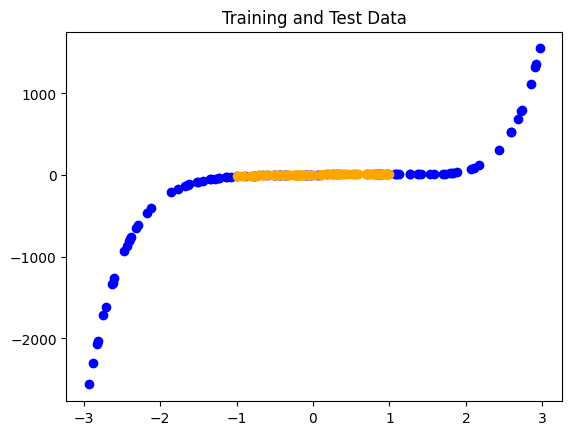

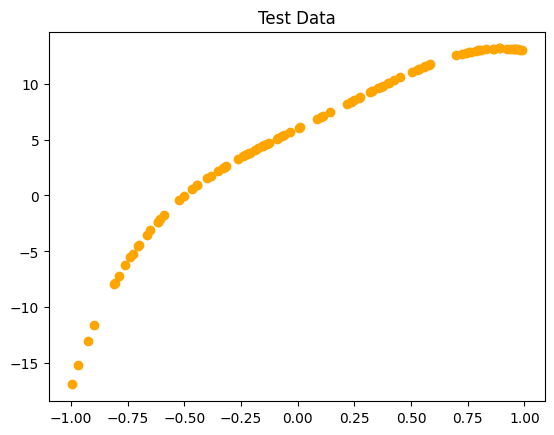

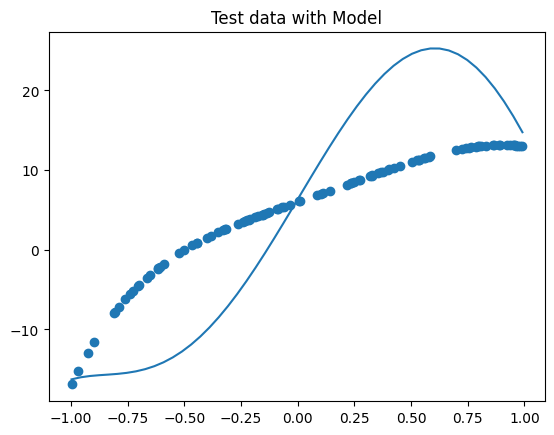

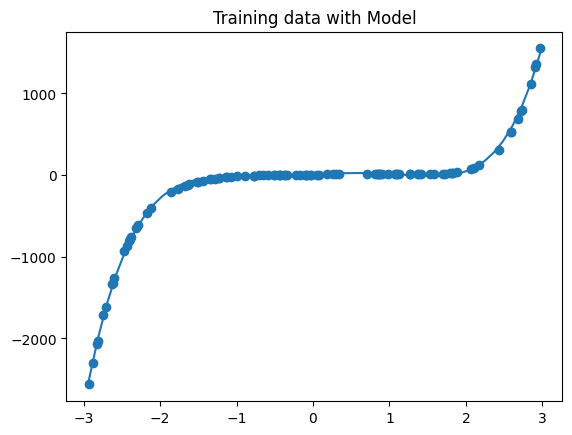

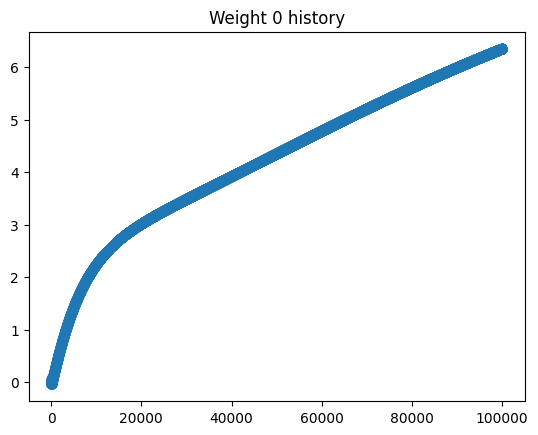

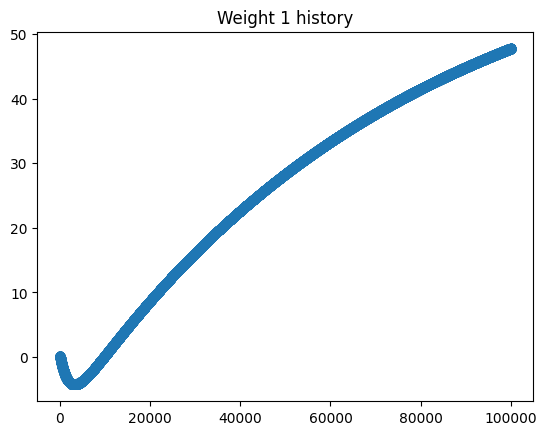

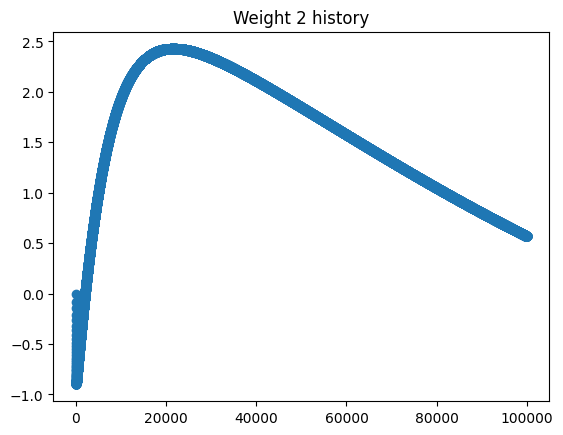

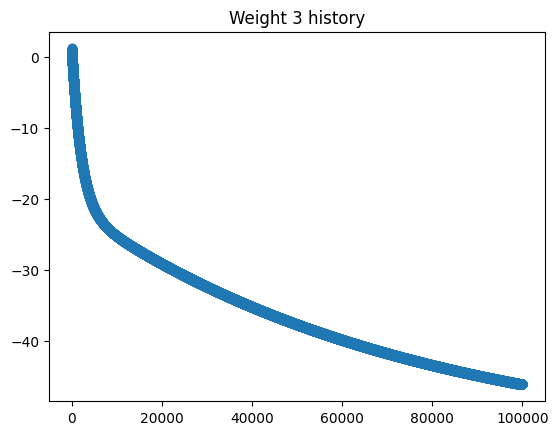

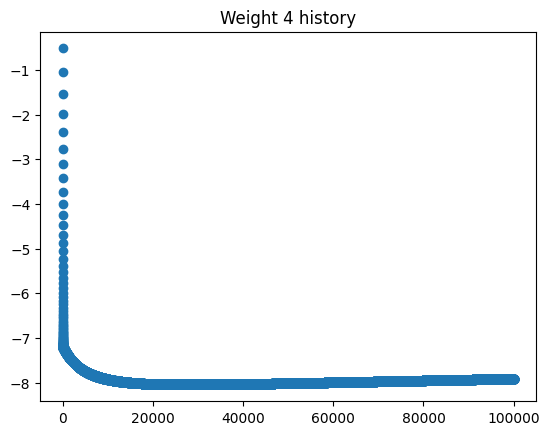

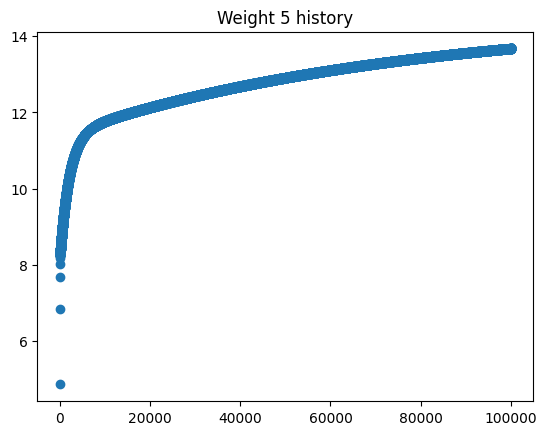

In [105]:
# Show results
plt.scatter(x_train, y_train, color="blue")
plt.scatter(x_test, y_test, color="orange")
plt.title("Training and Test Data")
plt.show()


plt.scatter(x_test, y_test, color="orange")
plt.title("Test Data")
plt.show()


plt.scatter(x_test, y_test)
x_space = np.linspace(np.min(x_test), np.max(x_test))
num_weights = len(weights)
model_predictions =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
plt.plot(x_space, model_predictions)
plt.title("Test data with Model")
plt.show()

plt.scatter(x_train, y_train)
x_space = np.linspace(np.min(x_train), np.max(x_train))
num_weights = len(weights)
model_predictions =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
plt.plot(x_space, model_predictions)
plt.title("Training data with Model")
plt.show()


# Plot history of each parameter
weight_history = np.array(weight_history)
for i in range(len(weights)):
    data = weight_history[:,i]
    plt.scatter([i for i in range(0, len(data))], data)
    plt.title(f"Weight {i} history")
    plt.show()


# Part 2

## Status: working on loading CSVs correctly, then planning on running "learn" function on one to get it to work, then find a way to return a predicted error or other metric and run on all in loop, and pick the best fit one

In [106]:
import matplotlib.pyplot as plt
import numpy as np

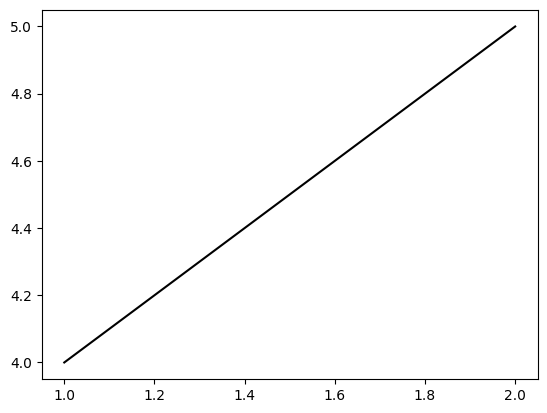

In [107]:

first_x = 1
last_x = 2
bias = 3
learned_slope = 1
plt.plot([first_x, last_x], [bias + first_x * learned_slope, bias + last_x * learned_slope], color="black")
plt.show()

In [108]:
data_formats = {'names': ('id', 'baths', 'land', 'living', 'garages', 'rooms','beds','age', 'price'), 'formats':('i2', 'f2', 'f4','f4', 'f4', 'i4', 'i4','i4','f8')}
housing_train = np.loadtxt("train.csv", delimiter=',', skiprows=1, dtype=data_formats)
housing_test = np.loadtxt("test.csv", delimiter=',', skiprows=1, dtype=data_formats)
#House ID,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Price

housing_train_output = housing_train["price"]

for n in data_formats["names"]:
    if n == 'price':
        continue
    print("\n\n", n)
    housing_train_input = housing_train[n]

    learned_slope, bias, slope_history, bias_history, error_history, final_loss = learn(200, housing_train_input, housing_train_output)
    print(f"Learned slope: {learned_slope}")
    print(f"Learned bias: {bias}")
    print(f"Equation: h(x) = {learned_slope}x + {bias}")
    print(f"Loss is {final_loss}")

    plt.scatter(housing_train_input, housing_train_output)
    first_x = np.min(housing_train_input)
    last_x = np.max(housing_train_input)
    plt.plot([first_x, last_x], [bias - first_x * learned_slope, bias + last_x * learned_slope], color="black")
    plt.title(f"Price vs {n}")
    plt.show()



 id


TypeError: learn() missing 1 required positional argument: 'y_train'